In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.decomposition import PCA
import joblib


In [5]:
df = pd.read_csv("D:/Machine Learning datasets/Classification/stroke_dataset.csv")

print(df.head())
print(df.info())
print(df.describe())

   id  gender  age  hypertension  heart_disease ever_married      work_type  \
0   1    Male   44             1              0          Yes        Private   
1   2  Female   15             0              0          Yes  Self-employed   
2   3  Female   55             0              0          Yes   Never_worked   
3   4  Female   72             0              0          Yes   Never_worked   
4   5    Male   38             1              0           No       children   

  Residence_type  avg_glucose_level    bmi   smoking_status  stroke  
0          Urban             136.71  29.10     never smoked       0  
1          Urban              77.12  27.01  formerly smoked       1  
2          Rural             141.59  22.63     never smoked       0  
3          Rural             128.37  14.59           smokes       0  
4          Rural             135.48  28.36           smokes       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 12 columns):


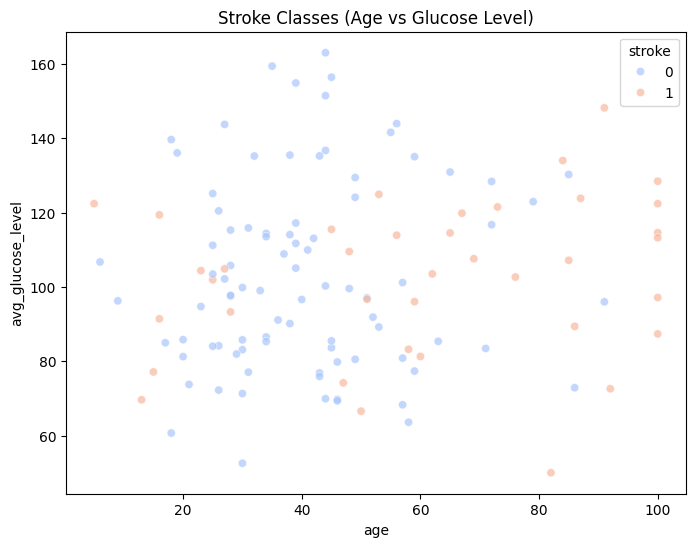

In [6]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="age",
    y="avg_glucose_level",
    hue="stroke",
    palette="coolwarm",
    alpha=0.7
)
plt.title("Stroke Classes (Age vs Glucose Level)")
plt.show()


In [7]:
def handle_outliers_iqr(data, cols):
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        data[col] = np.where(
            data[col] < lower, lower,
            np.where(data[col] > upper, upper, data[col])
        )
    return data

num_cols = df.select_dtypes(include=["int64","float64"]).columns.drop("stroke")
df = handle_outliers_iqr(df, num_cols)


In [8]:
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

num_cols = df.select_dtypes(include=["int64","float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])


In [9]:
X = df.drop("stroke", axis=1)
y = df["stroke"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [11]:
print(pd.DataFrame(X_train_scaled).describe())


                 0             1             2             3      4   \
count  1.000000e+02  1.000000e+02  1.000000e+02  1.000000e+02  100.0   
mean  -3.996803e-17 -8.881784e-18 -2.220446e-17 -4.440892e-18    0.0   
std    1.005038e+00  1.005038e+00  1.005038e+00  1.005038e+00    0.0   
min   -1.740178e+00 -1.040833e+00 -1.774911e+00 -1.040833e+00    0.0   
25%   -8.520468e-01 -1.040833e+00 -7.993319e-01 -1.040833e+00    0.0   
50%   -1.986058e-02  9.607689e-01 -1.453721e-01  9.607689e-01    0.0   
75%    8.682710e-01  9.607689e-01  4.978671e-01  9.607689e-01    0.0   
max    1.756403e+00  9.607689e-01  2.256054e+00  9.607689e-01    0.0   

                 5             6             7             8             9   \
count  1.000000e+02  1.000000e+02  1.000000e+02  1.000000e+02  1.000000e+02   
mean   1.043610e-16  4.218847e-17  1.110223e-17 -5.329071e-17  1.617595e-15   
std    1.005038e+00  1.005038e+00  1.005038e+00  1.005038e+00  1.005038e+00   
min   -1.564697e+00 -1.572427e+00 -

In [12]:
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "SVM Linear": SVC(kernel="linear", probability=True),
    "Naive Bayes": GaussianNB(),
    "SVM Poly d=2": SVC(kernel="poly", degree=2, probability=True),
    "SVM Poly d=3": SVC(kernel="poly", degree=3, probability=True)
}


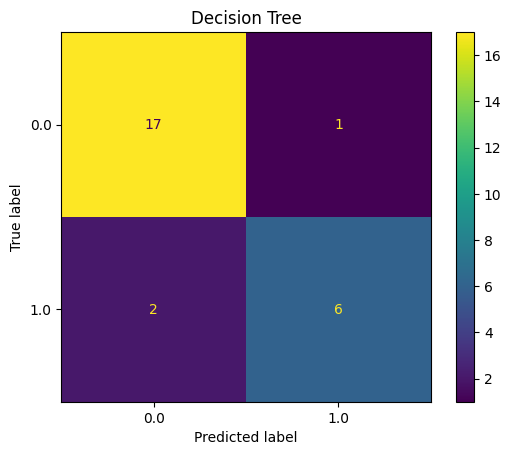

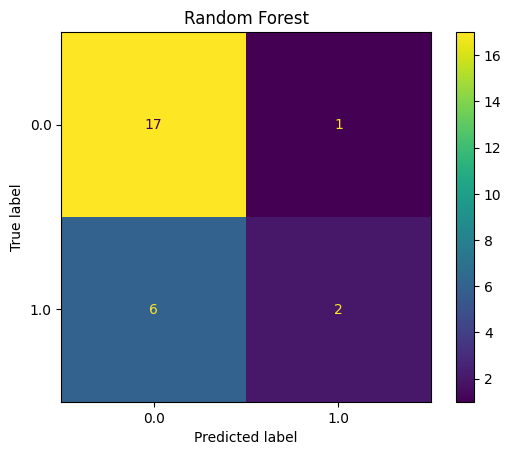

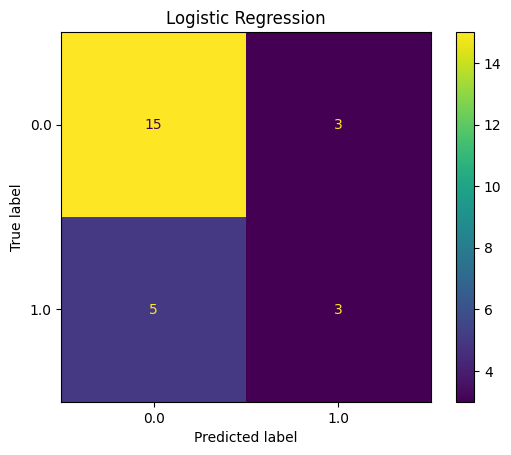

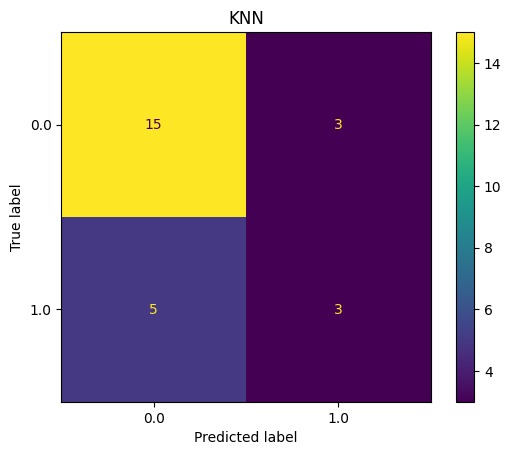

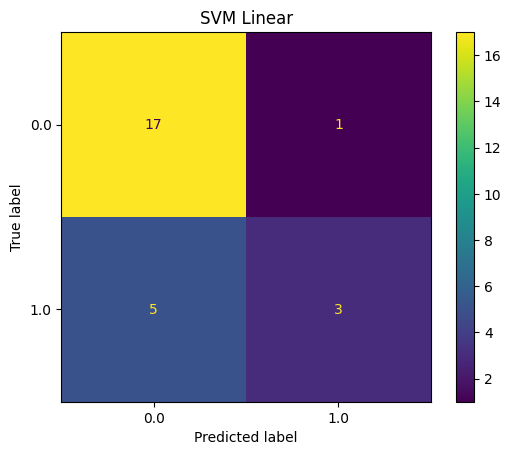

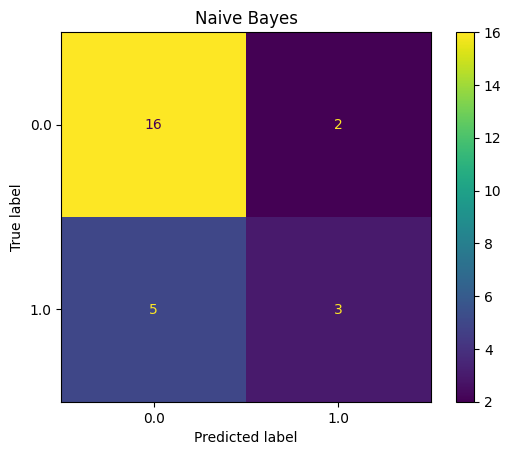

C:\Users\Admin\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


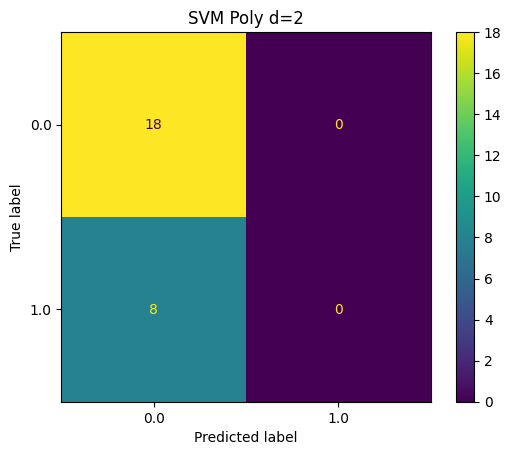

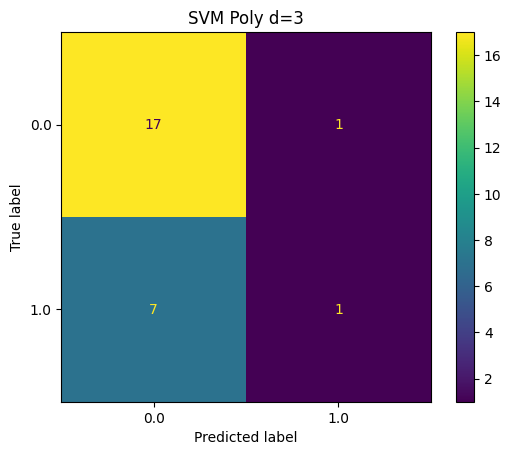

                 Model  Accuracy  Precision  Recall  F1 Score   ROC-AUC
0        Decision Tree  0.884615   0.857143   0.750  0.800000  0.843750
1        Random Forest  0.730769   0.666667   0.250  0.363636  0.802083
2  Logistic Regression  0.692308   0.500000   0.375  0.428571  0.604167
3                  KNN  0.692308   0.500000   0.375  0.428571  0.788194
4           SVM Linear  0.769231   0.750000   0.375  0.500000  0.604167
5          Naive Bayes  0.730769   0.600000   0.375  0.461538  0.722222
6         SVM Poly d=2  0.692308   0.000000   0.000  0.000000  0.694444
7         SVM Poly d=3  0.692308   0.500000   0.125  0.200000  0.555556


In [13]:
results = []
roc_data = {}

def evaluate(model, name):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(name)
    plt.show()

for name, model in models.items():
    evaluate(model, name)

results_df = pd.DataFrame(results)
print(results_df)


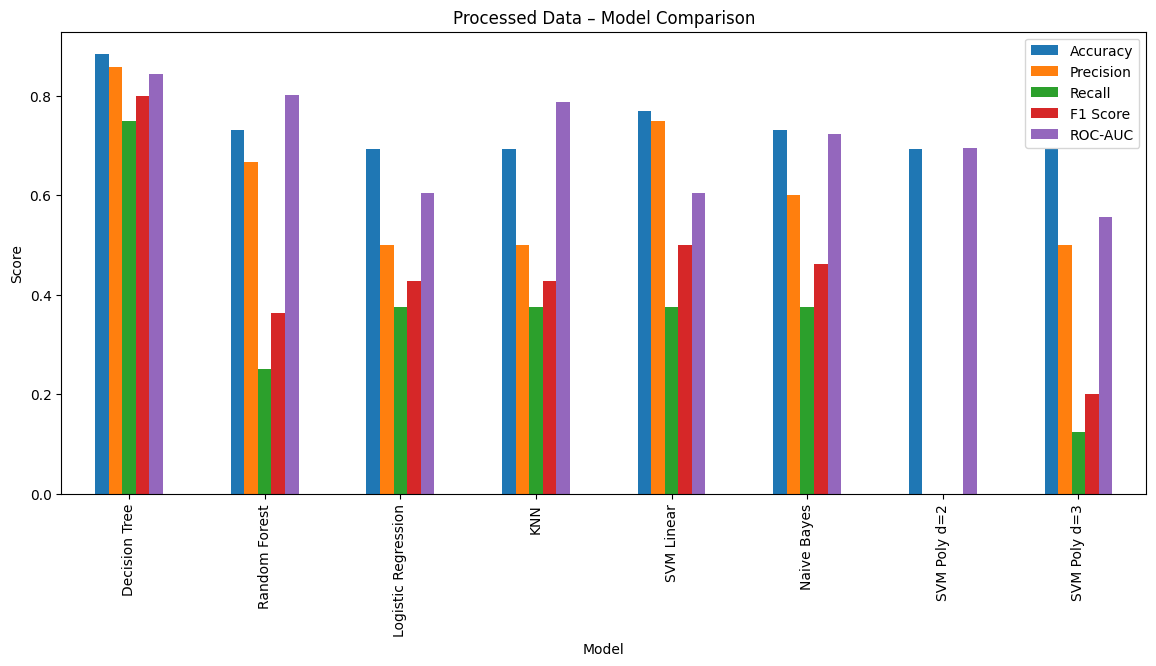

In [14]:
results_df.set_index("Model").plot(kind="bar", figsize=(14,6))
plt.title("Processed Data – Model Comparison")
plt.ylabel("Score")
plt.show()


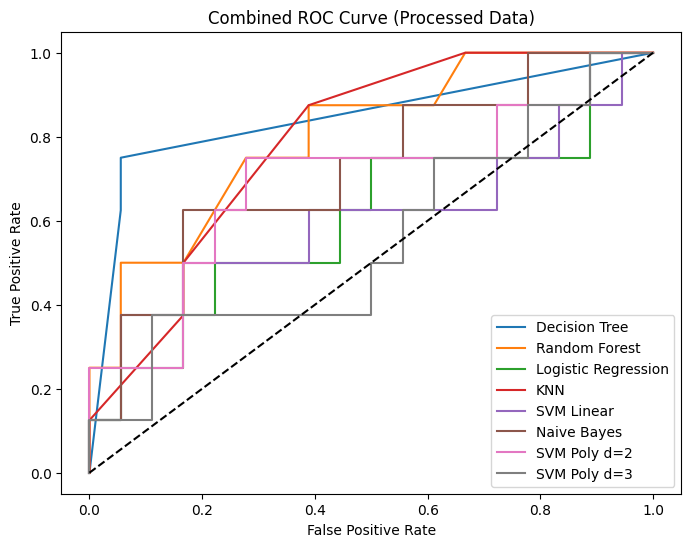

In [15]:
plt.figure(figsize=(8,6))
for name, (fpr, tpr) in roc_data.items():
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Combined ROC Curve (Processed Data)")
plt.legend()
plt.show()


In [16]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    print(f"{name} → Train: {train_acc:.3f}, Test: {test_acc:.3f}")


Decision Tree → Train: 0.960, Test: 0.846
Random Forest → Train: 1.000, Test: 0.731
Logistic Regression → Train: 0.810, Test: 0.692
KNN → Train: 0.820, Test: 0.692
SVM Linear → Train: 0.840, Test: 0.769
Naive Bayes → Train: 0.850, Test: 0.731
SVM Poly d=2 → Train: 0.830, Test: 0.692
SVM Poly d=3 → Train: 0.850, Test: 0.692


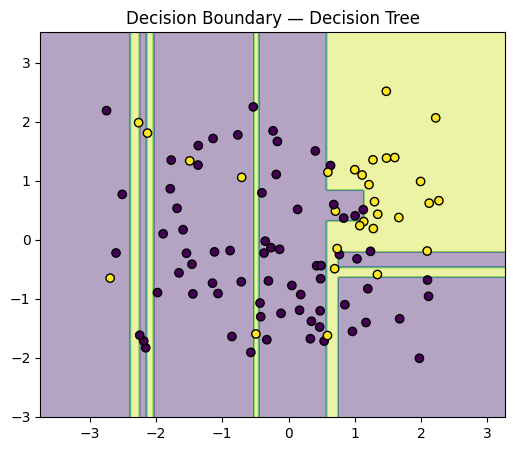

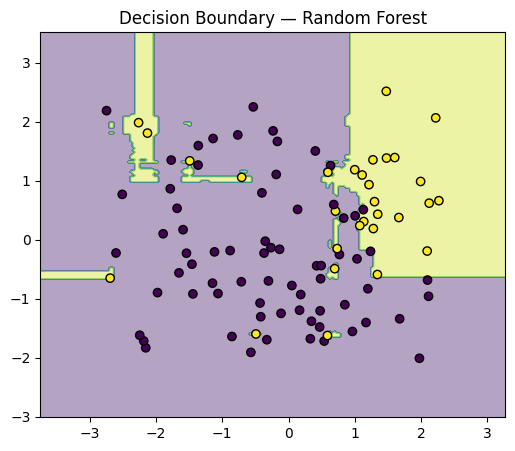

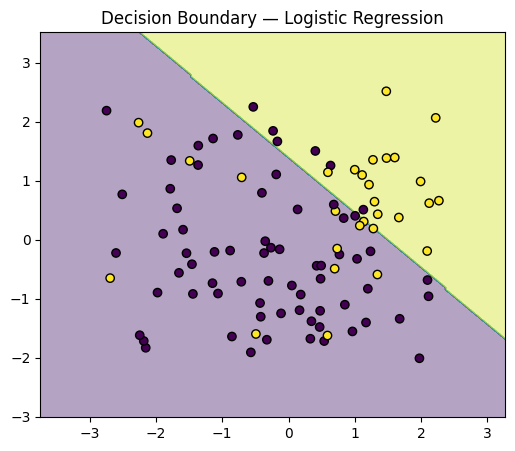

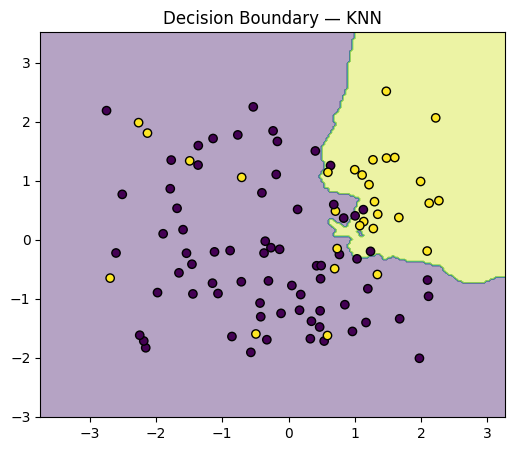

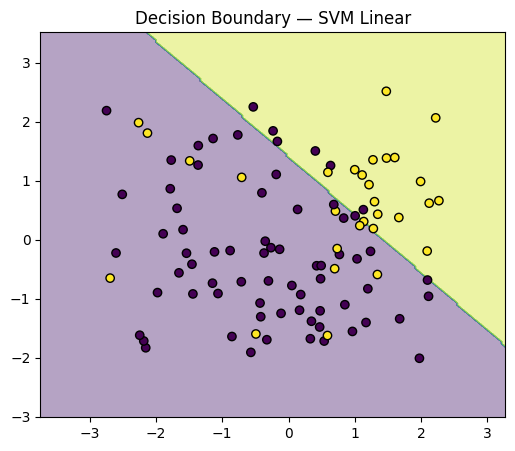

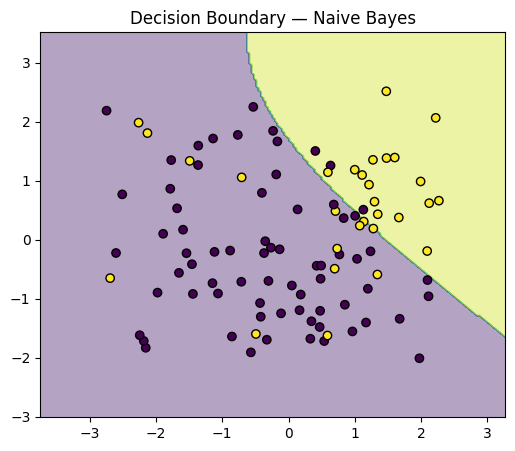

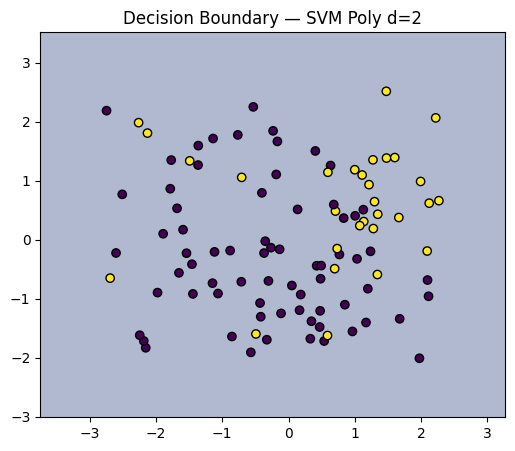

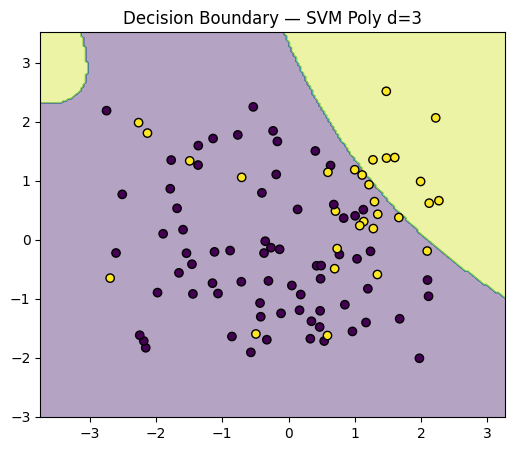

In [17]:
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_train_scaled)
y_vis = y_train.values

xx, yy = np.meshgrid(
    np.linspace(X_vis[:,0].min()-1, X_vis[:,0].max()+1, 200),
    np.linspace(X_vis[:,1].min()-1, X_vis[:,1].max()+1, 200)
)

for name, model in models.items():
    model.fit(X_vis, y_vis)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X_vis[:,0], X_vis[:,1], c=y_vis, edgecolor="k")
    plt.title(f"Decision Boundary — {name}")
    plt.show()


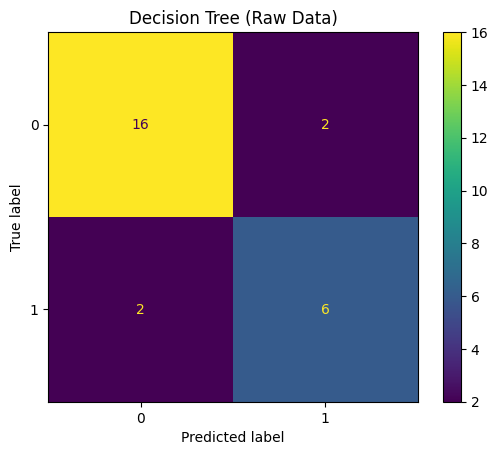

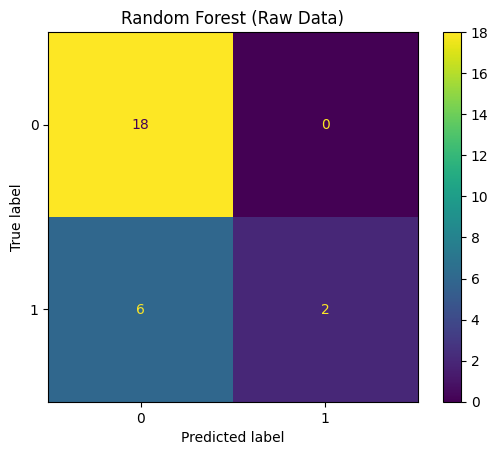

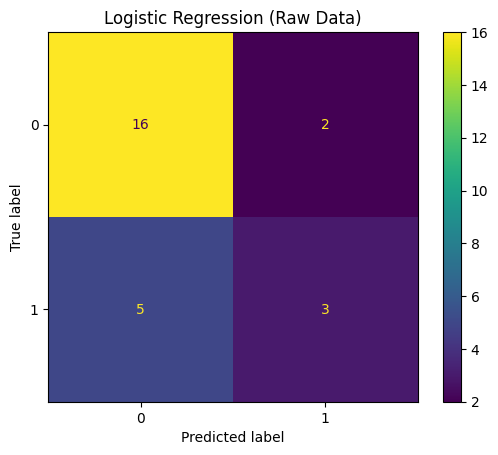

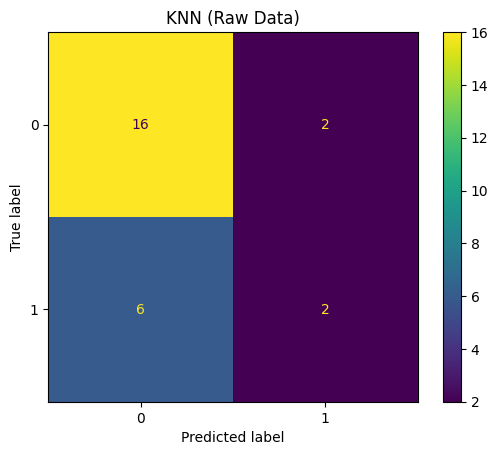

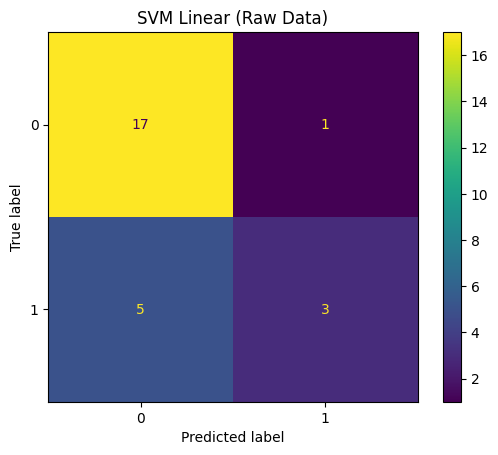

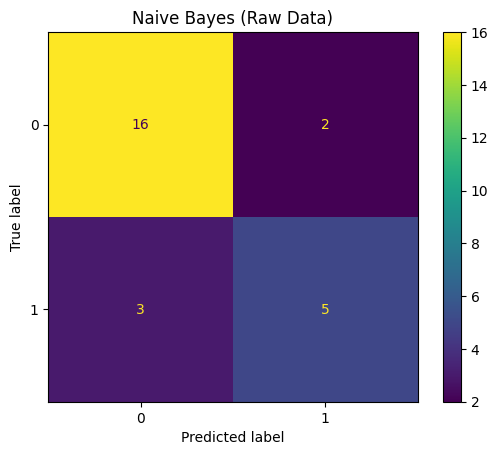

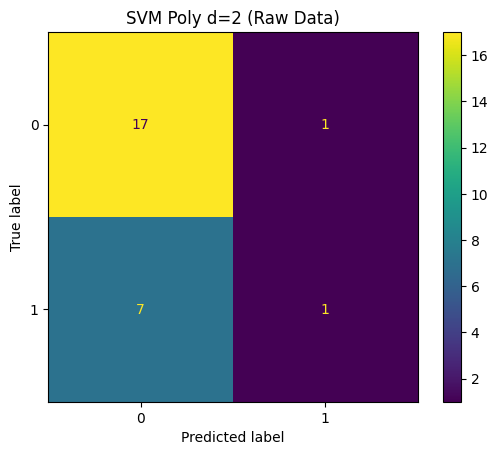

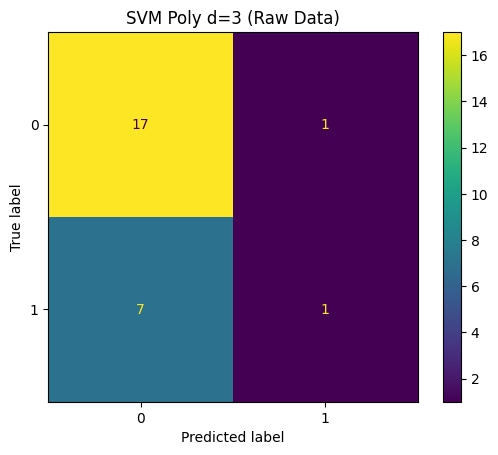

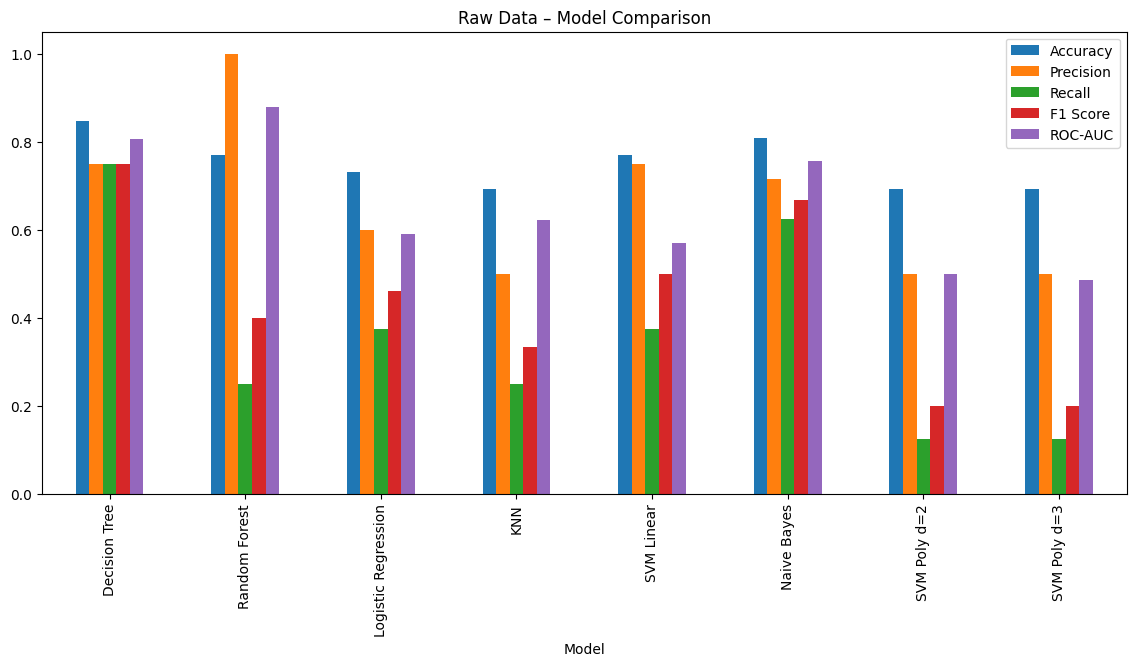

In [19]:
df_raw = pd.read_csv(r"D:/Machine Learning datasets/Classification/stroke_dataset.csv")

Xr = df_raw.drop("stroke", axis=1)
yr = df_raw["stroke"]

for col in Xr.select_dtypes(include="object").columns:
    Xr[col] = LabelEncoder().fit_transform(Xr[col])

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.2, random_state=42, stratify=yr
)

raw_results = []

for name, model in models.items():
    model.fit(Xr_train, yr_train)
    y_pred = model.predict(Xr_test)
    y_prob = model.predict_proba(Xr_test)[:,1]

    raw_results.append({
        "Model": name,
        "Accuracy": accuracy_score(yr_test, y_pred),
        "Precision": precision_score(yr_test, y_pred),
        "Recall": recall_score(yr_test, y_pred),
        "F1 Score": f1_score(yr_test, y_pred),
        "ROC-AUC": roc_auc_score(yr_test, y_prob)
    })

    ConfusionMatrixDisplay.from_predictions(yr_test, y_pred)
    plt.title(f"{name} (Raw Data)")
    plt.show()

raw_df = pd.DataFrame(raw_results)
raw_df.set_index("Model").plot(kind="bar", figsize=(14,6))
plt.title("Raw Data – Model Comparison")
plt.show()


In [21]:
joblib.dump(scaler, "scaler.pkl")
joblib.dump(df, "processed_stroke_data.pkl")

for name, model in models.items():
    joblib.dump(model, f"{name.replace(' ', '_')}.pkl")
